In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:


df=pd.read_csv(r"C:\Users\reham\Downloads\Banking.csv")
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [3]:
df.shape

(3000, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   str    
 1   Name                      3000 non-null   str    
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   str    
 5   Banking Contact           3000 non-null   str    
 6   Nationality               3000 non-null   str    
 7   Occupation                3000 non-null   str    
 8   Fee Structure             3000 non-null   str    
 9   Loyalty Classification    3000 non-null   str    
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loans         

In [5]:
df.dtypes

Client ID                       str
Name                            str
Age                           int64
Location ID                   int64
Joined Bank                     str
Banking Contact                 str
Nationality                     str
Occupation                      str
Fee Structure                   str
Loyalty Classification          str
Estimated Income            float64
Superannuation Savings      float64
Amount of Credit Cards        int64
Credit Card Balance         float64
Bank Loans                  float64
Bank Deposits               float64
Checking Accounts           float64
Saving Accounts             float64
Foreign Currency Account    float64
Business Lending            float64
Properties Owned              int64
Risk Weighting                int64
BRId                          int64
GenderId                      int64
IAId                          int64
dtype: object

In [6]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool

In [8]:
has_duplicates = df['Client ID'].duplicated().sum()
print(has_duplicates)

60


In [9]:
duplicates = df[df['Client ID'].duplicated(keep=False)]
print(duplicates)

     Client ID             Name  Age  Location ID Joined Bank  \
27    IND35589    Jimmy Simpson   52        38270  08-01-2018   
53    IND54314      Kevin Gomez   32        24168  01-01-2007   
54    IND74305    Ronald Larson   29        25730  11-12-1999   
57    IND26283    Joshua Hughes   58           95  21-04-2006   
71    IND49489     Keith Weaver   74         4567  09-08-1995   
...        ...              ...  ...          ...         ...   
2948  IND28199       Jesse Wood   70        30301  28-02-2002   
2962  IND85232     Gary Perkins   76        33822  12-02-2007   
2963  IND43081    Gregory Meyer   28        42699  05-07-2003   
2968  IND80089      Johnny Ryan   79        18443  31-12-2009   
2976  IND54095  William Alvarez   44        24211  23-03-2003   

          Banking Contact Nationality                   Occupation  \
27           George Lewis    European          Geological Engineer   
53            Jerry Green    European              Project Manager   
54       

In [10]:
df= df.drop_duplicates(subset='Client ID', keep='first')

In [11]:
df["Properties Owned"].unique()

array([1, 0, 2, 3])

In [12]:
df["Estimated Income"].min()

np.float64(15919.48)

In [13]:
bins=[0,100000,300000,float('inf')]
labs=["low","mid","high"]
df["income band"]=pd.cut(df["Estimated Income"],bins=bins,labels=labs,right=False)

In [14]:
df["income band"]

0        low
1        mid
2        mid
3       high
4        mid
        ... 
2995     mid
2996     low
2997     low
2998     mid
2999     low
Name: income band, Length: 2940, dtype: category
Categories (3, str): ['low' < 'mid' < 'high']

<Axes: xlabel='income band', ylabel='count'>

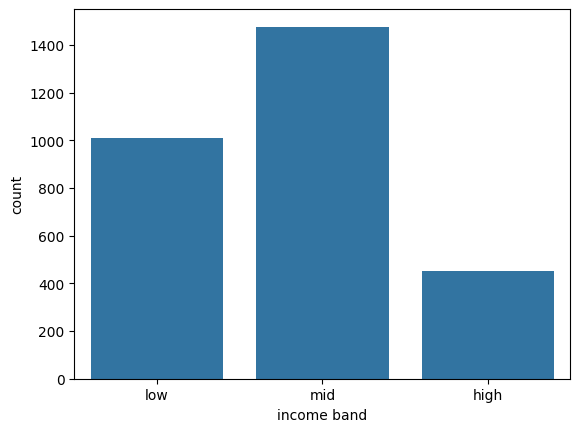

In [15]:
sns.countplot(x=df["income band"])

In [16]:
df["GenderId"] = df["GenderId"].map({1: "Male", 2: "Female"})

In [17]:
df["Banking relationship"] = df["BRId"].replace({
    1: "Retail",
    2: "Institutional",
    3: "Private Bank",
    4: "Commercial"
})

In [18]:
df["Investment Advisor"] = df["IAId"].replace({
    1: "Victor Dean",
    2: "Jeremy Porter",
    3: "Ernest Knight",
    4: "Eric Shaw",
    5: "Kevin Kim",
    6: "Victor Rogers",
    7: "Eugene Cunningham",
    8: "Joe Carroll",
    9: "Steve Sanchez",
    10: "Lawrence Sanchez",
    11: "Peter Castillo",
    12: "Victor Gutierrez",
    13: "Daniel Carroll",
    14: "Carl Anderson",
    15: "Nicholas Ward",
    16: "Fred Bryant",
    17: "Ryan Taylor",
    18: "Sean Vasquez",
    19: "Nicholas Morrison",
    20: "Jack Phillips",
    21: "Juan Ramirez",
    22: "Gregory Boyd"
})

In [19]:
categorical_cols = ["Banking relationship", "GenderId", "Investment Advisor",
                    "Nationality", "Occupation", "Fee Structure",
                    "Loyalty Classification"]
for col in categorical_cols:
  print(f"Value Counts for '{col}':")
  display(df[col].value_counts())

Value Counts for 'Banking relationship':


Banking relationship
Private Bank     1318
Retail            650
Institutional     488
Commercial        484
Name: count, dtype: int64

Value Counts for 'GenderId':


GenderId
Female    1487
Male      1453
Name: count, dtype: int64

Value Counts for 'Investment Advisor':


...

Occupation
Associate Professor             26
Structural Analysis Engineer    26
Recruiter                       25
Account Coordinator             24
Human Resources Manager         24
                                ..
Database Administrator IV        8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64

Value Counts for 'Fee Structure':


Fee Structure
High    1441
Mid      944
Low      555
Name: count, dtype: int64

Value Counts for 'Loyalty Classification':


Loyalty Classification
Jade        1304
Silver       754
Gold         574
Platinum     308
Name: count, dtype: int64

<Axes: xlabel='income band', ylabel='count'>

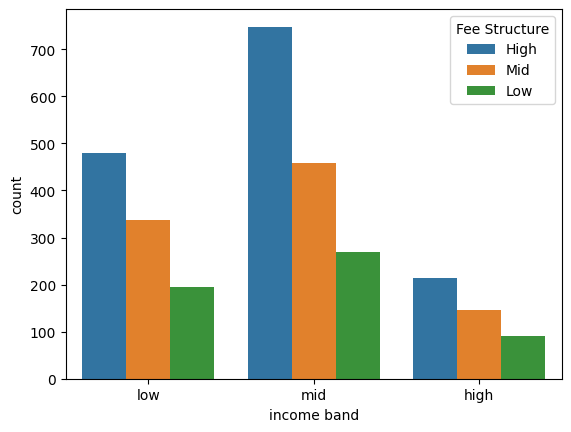

In [40]:
plt.Figure(figsize=(10,6))
sns.countplot(x="income band",hue="Fee Structure" , data=df)

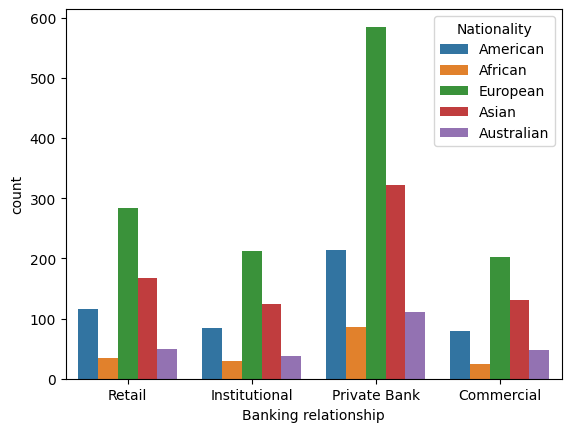

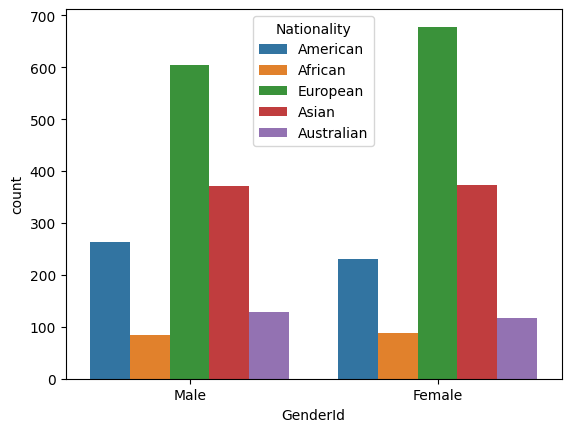

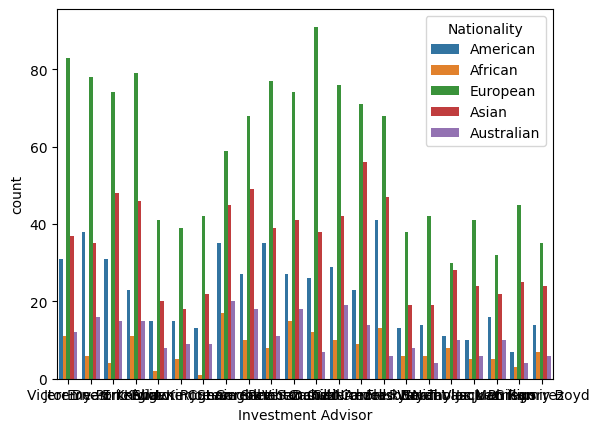

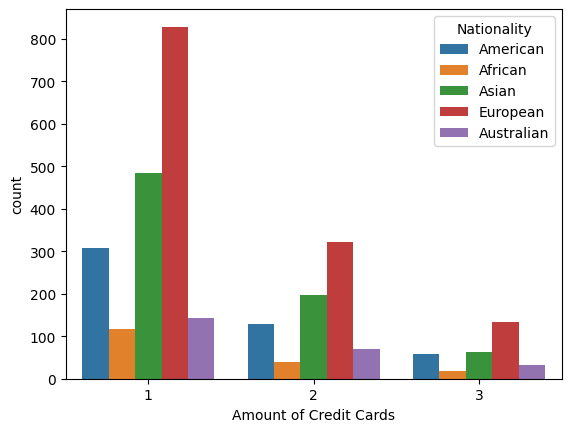

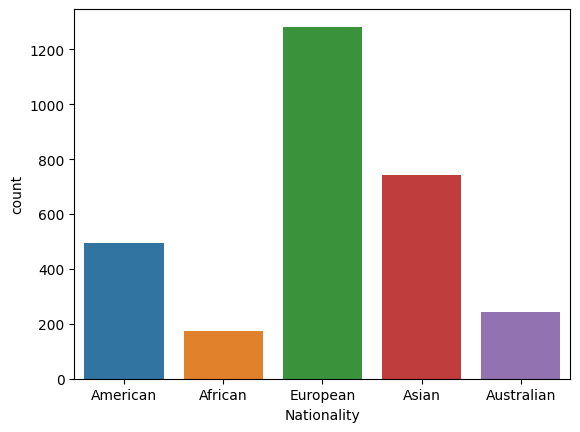

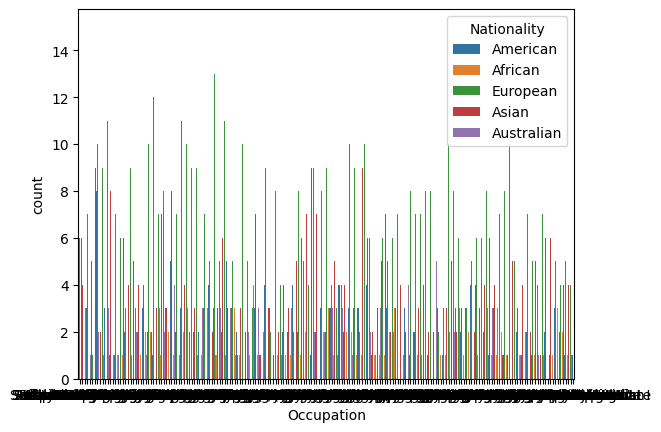

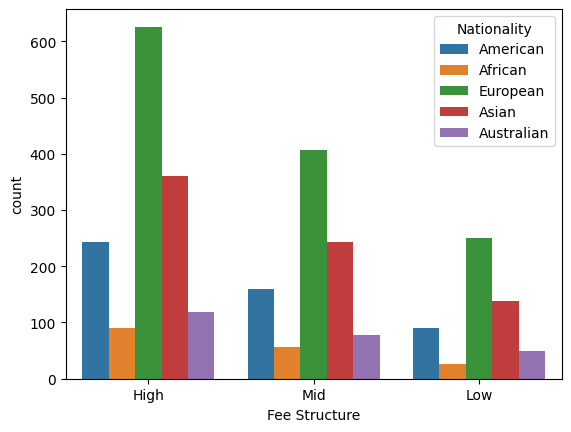

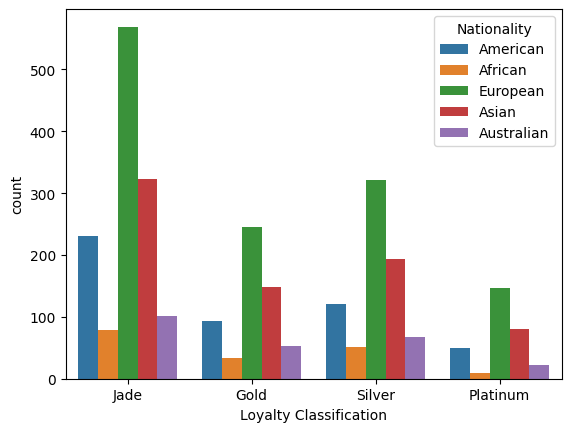

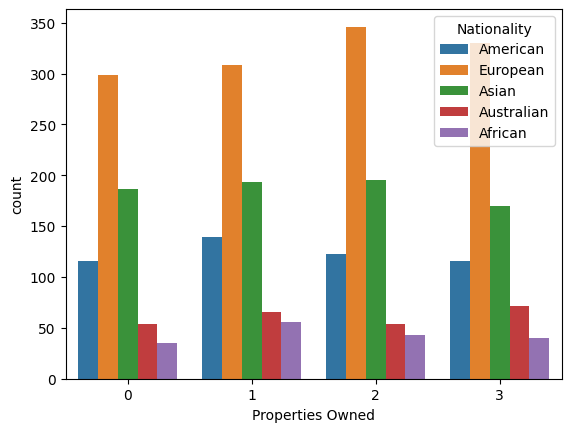

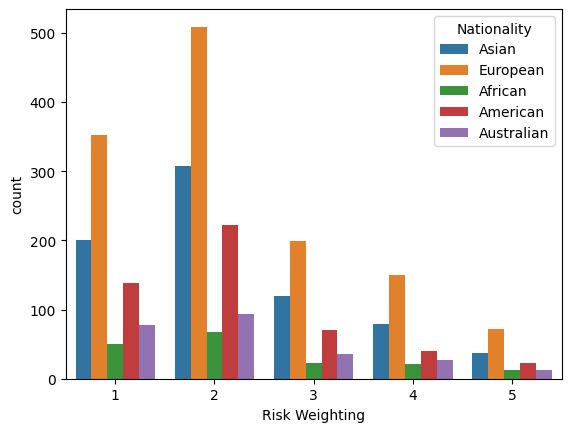

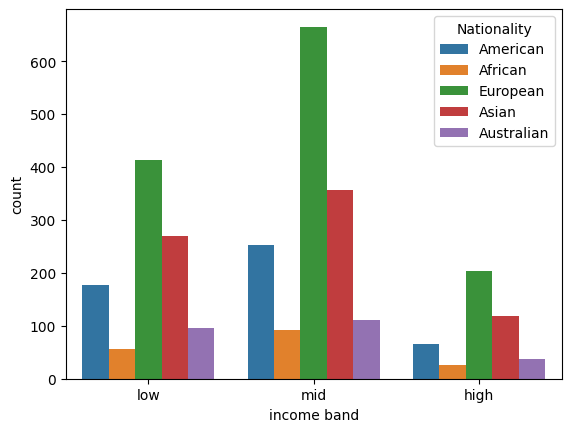

In [20]:
for i, predictor in enumerate(df[["Banking relationship", "GenderId", "Investment Advisor", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "income band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Nationality')

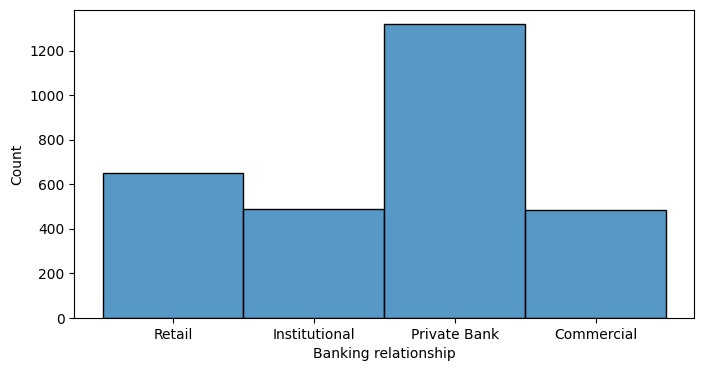

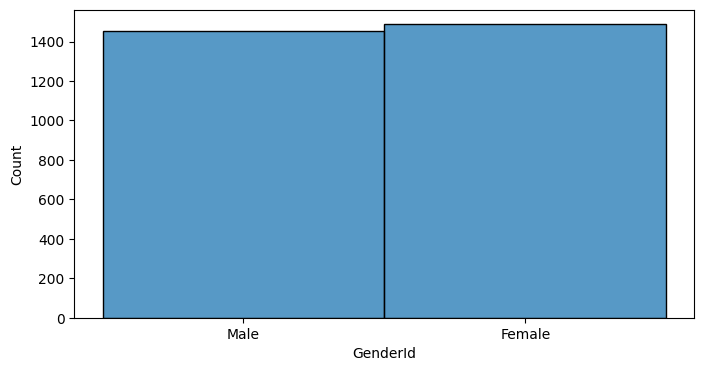

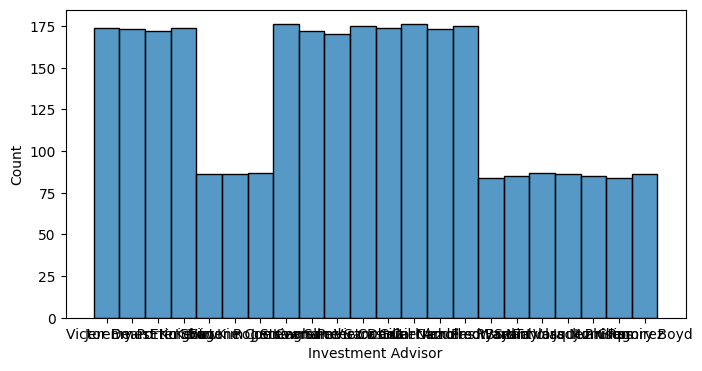

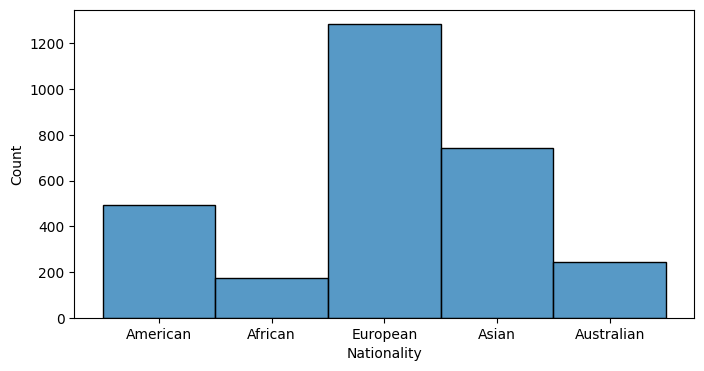

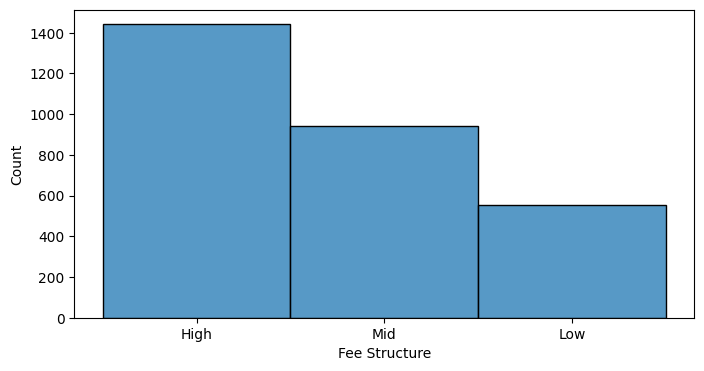

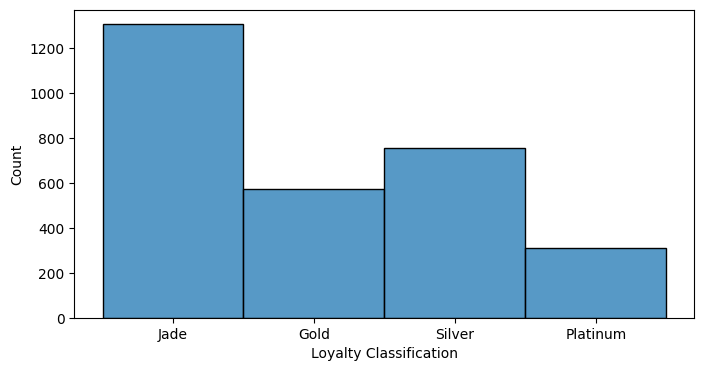

In [21]:
for col in categorical_cols:
  if col == "Occupation":
    continue
  plt.figure(figsize=(8,4))
  sns.histplot(df[col])

  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

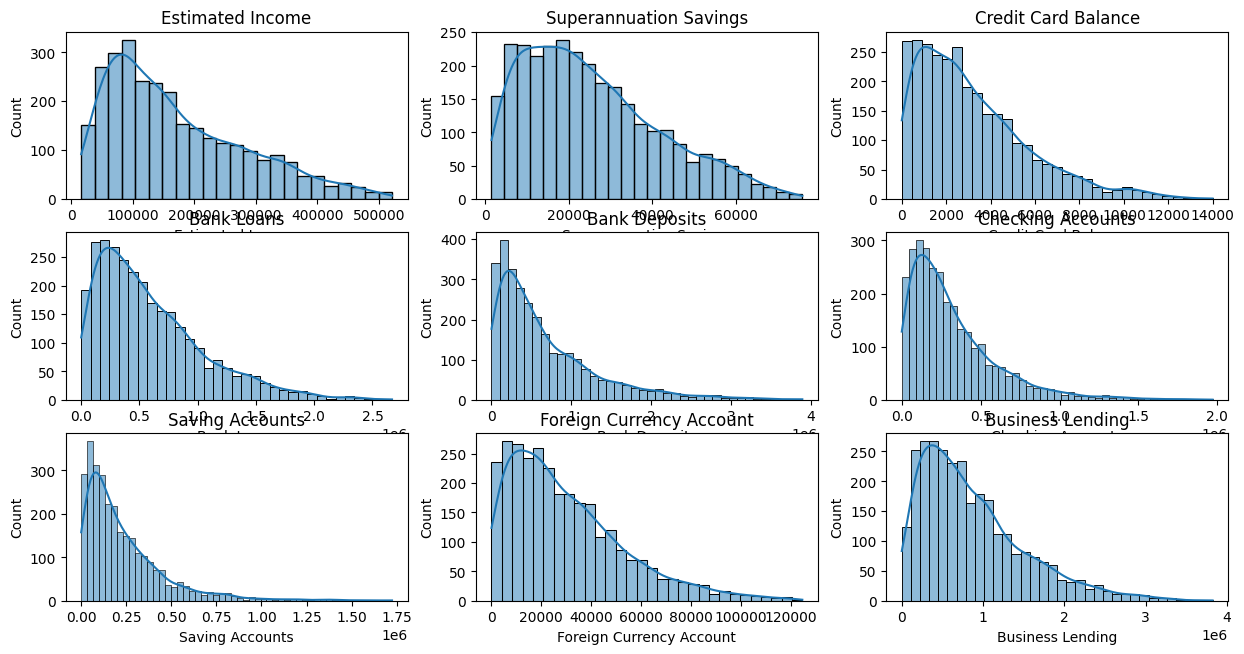

In [22]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
  plt.subplot(4,3,i+1)
  sns.histplot(df[col],kde=True)
  plt.title(col)
plt.show()

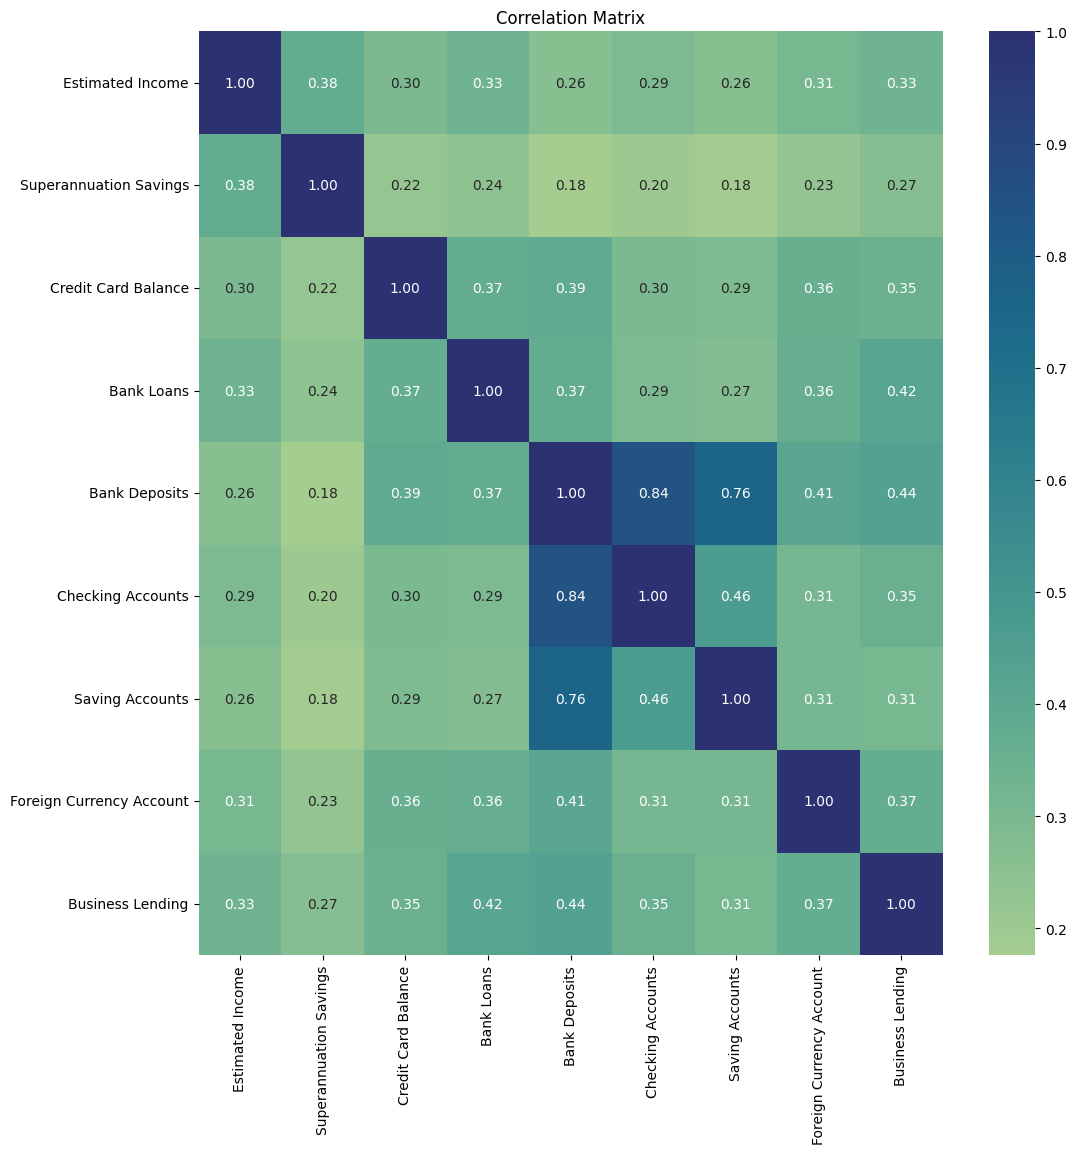

In [23]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='Risk Weighting', ylabel='Estimated Income'>

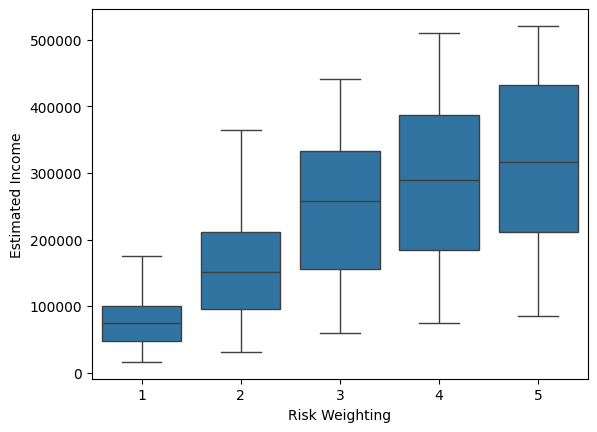

In [29]:
sns.boxplot(x="Risk Weighting", y="Estimated Income", data=df)

In [25]:
df=df.drop(columns=["IAId","BRId"])

In [26]:
df.to_csv(r"C:\Users\reham\Downloads\Banking_cleaned.csv", index=False)

In [27]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'GenderId', 'income band', 'Banking relationship',
       'Investment Advisor'],
      dtype='str')